# Google Maps: Ann Arbor Restaurants

In [ ]:
import pandas as pd
import seaborn as sb
import numpy as np

In [ ]:
file_path = "" # REPLACE
df = pd.read_csv(file_path)

## Modeling the CLT

<Axes: ylabel='Count'>

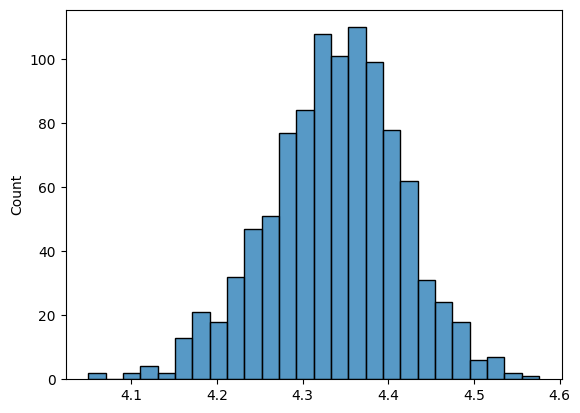

In [ ]:
sample_means = [df['totalScore'].sample(n=30, replace=True).mean() for _ in range(1000)]
sb.histplot(sample_means)

<Axes: ylabel='Count'>

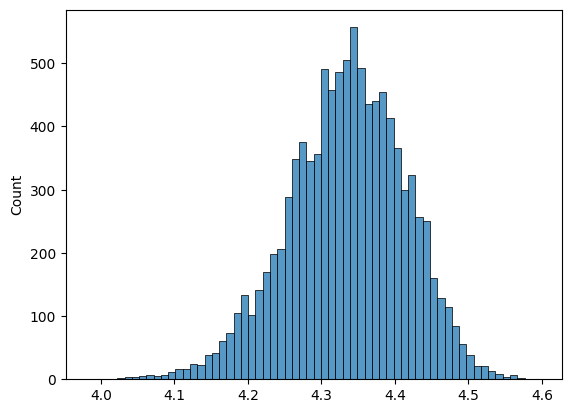

In [ ]:
sample_means = [df['totalScore'].sample(n=30, replace=True).mean() for _ in range(10000)]
sb.histplot(sample_means)

## Two Sample t-test

In [ ]:
df['neighborhood'].value_counts()

,count
neighborhood,
Burns Park,42
Lakewood,20
Old West Side,19
Bryant Pattengill East,14
Dartmoor,14
Bryant Pattengill West,13
Angell,10
Northside,7
Abbot,6


In [ ]:
# Two sample t-test: Difference of means Hypothesis Test for restaurants in Lakewood are more popular than restaurants in the Old West Side
lakewood = df[df['neighborhood'] == 'Lakewood']['totalScore'].dropna()
old_west_side = df[df['neighborhood'] == 'Old West Side']['totalScore'].dropna()
sem = np.sqrt(lakewood.var()/len(lakewood) + old_west_side.var()/len(old_west_side))
z = (lakewood.mean() - old_west_side.mean()) / sem
z

np.float64(-1.625961254150922)

## Chi Square Test of Independence

Is the presence of outdoor seating independent from having a high rating?

In [ ]:
import scipy.stats as sps
contingency_tbl = pd.crosstab(df['additionalInfo.Service_options.Outdoor_seating'], df['totalScore'] > 4.0)
contingency_tbl

totalScore,False,True
additionalInfo.Service_options.Outdoor_seating,,
False,37,88
True,8,67


In [ ]:
chi2_stat, p_value, dof, expected = sps.chi2_contingency(contingency_tbl)
p_value

np.float64(0.0033966581036733103)

## KMeans Clustering with Location Data

In [ ]:
from sklearn.cluster import KMeans

In [ ]:
df_clean = df.dropna(subset=['location.lat', 'location.lng', 'additionalInfo.Crowd.College_students']).copy()

In [ ]:
coords = df_clean[['location.lat', 'location.lng']]

# Run KMeans with 3 clusters
kmeans = KMeans(n_clusters=3, random_state=101)
df_clean['location_cluster'] = kmeans.fit_predict(coords)

<Axes: xlabel='location.lng', ylabel='location.lat'>

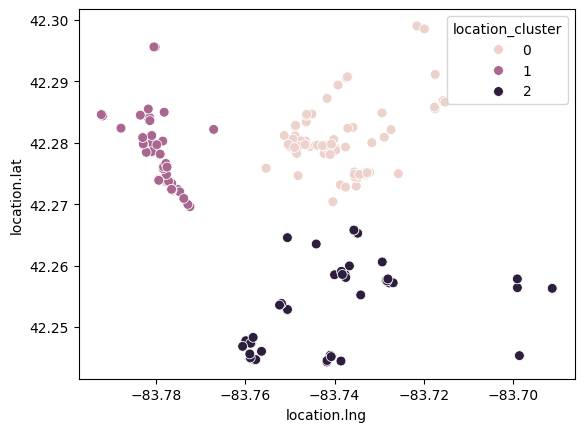

In [ ]:
sb.scatterplot(data=df_clean, x='location.lng', y='location.lat', hue='location_cluster', s=50)

In [ ]:
# Compute proportion of restaurants with a college crowd for each cluster
group_means = df_clean.groupby('location_cluster')['additionalInfo.Crowd.College_students'].mean()
print("Proportion of Restaurants with a College Student Crowd by Cluster:\n", group_means)

Proportion of Restaurants with a College Student Crowd by Cluster:
 location_cluster
0    0.576923
1    0.306122
2    0.489362
Name: additionalInfo.Crowd.College_students, dtype: float64
